In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
    "use_gpu":use_gpu
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
  #  "use_gpu":use_gpu
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

# [ 1.00000000e+06,  1.00000000e+04,  9.00000000e-01,
#          2.85813146e+01,  5.00000000e-01,  1.00000000e+00,
#          3.31765439e+01,  1.04719755e+00,  7.85398163e-01,
#          6.28318531e-01,  5.23598776e-01,  1.00000000e-01,
#          2.00000000e-01,  3.00000000e-01,  1.00000000e+01,
#          2.50000000e-01,  9.50000000e-01]

m1 = 1e6
m2 = 1e4
a = 0.9 
p0 = 2.85813146e+01
#p0 = 42.0
e0 = 5.00000000e-01
xI0 = 1.0
dist = 3.31765439e+01/2
#dist = 5.0
qS = 1.04719755e+00
phiS = 7.85398163e-01
qK = 6.28318531e-01

phiK =5.23598776e-01
Phi_phi0 = 0.1
Phi_theta0 =0.2
Phi_r0 = 0.3

dt = 10.0
T = 0.25
chi2 = 9.50000000e-01

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [4]:
der_order = 8
Ndelta=10
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape: (2, 788954)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10000.0, 0.9, 28.5813146, 0.5, 1.0, 16.58827195, 1.04719755, 0.785398163, 0.628318531, 0.523598776, 0.1, 0.2, 0.3, 0.95, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  20.191430390900702


Body is not plunging, Fisher should be stable.
waveform shape: (2, 788954)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10000.0, 0.9, 28.5813146, 0.5, 1.0, 16.58827195, 1.04719755, 0.785398163, 0.628318531, 0.523598776, 0.1, 0.2, 0.3, 0.95, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 20.191430390900702
calculating stable deltas...
Gamma_ii for m1: 15.115372492567934
Gamma_ii for m1: 15.115372491894409
Gamma_ii for m1: 15.115372491265363
Gamma_ii for m1: 15.115372490979535
Gamma_ii for m1: 15.115372492355489
Gamma_ii for m1: 15.115372498156908
Gamma_ii for m1: 15.115372479366775
Gamma_ii for m1: 15.115372171271133
Gamma_ii for m1: 15.115371450066835
Gamma_ii for m1: 15.115378883330184
[np.float64(4.455895717720586e-11), np.float64(4.161625925452773e-11), np.float64(1.8909772162608037e-11), np.float64(9.103008040307565e-11), np.float64(3.8380925046446777e-10), np.float64(1.243114181865221e-09), np.float64(2.0382934535294293e-08), np.float64

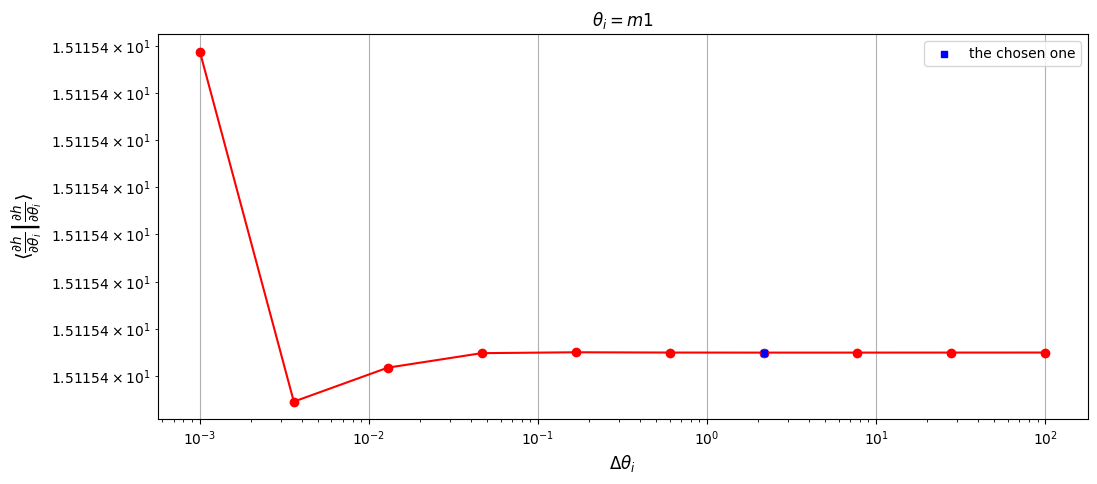

Gamma_ii for m2: 25229.35270486013
Gamma_ii for m2: 25229.3527035849
Gamma_ii for m2: 25229.352703958368
Gamma_ii for m2: 25229.352697791048
Gamma_ii for m2: 25229.35269139893
Gamma_ii for m2: 25229.352704883328
Gamma_ii for m2: 25229.35294223423
Gamma_ii for m2: 25229.352149086968
Gamma_ii for m2: 25229.35674099334
Gamma_ii for m2: 25229.367732578157
[np.float64(5.054555462317028e-11), np.float64(1.480290171375763e-11), np.float64(2.4445018571761756e-10), np.float64(2.533603623186606e-10), np.float64(5.344725962208406e-10), np.float64(9.407728449743563e-09), np.float64(3.143748029301887e-08), np.float64(1.8200647831094437e-07), np.float64(4.356662812697491e-07)]
1


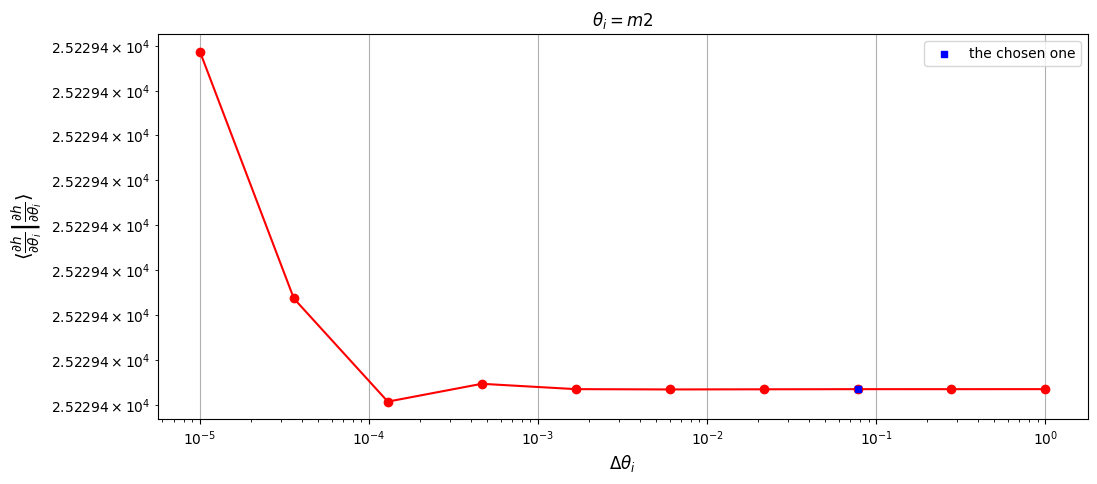

Gamma_ii for a: 32724961681.609524
Gamma_ii for a: 32724982002.933662
Gamma_ii for a: 32724742948.396564
Gamma_ii for a: 32725239873.985237
Gamma_ii for a: 32725883587.078968
Gamma_ii for a: 32721681437.98654
Gamma_ii for a: 32729449920.72814
Gamma_ii for a: 32733990255.179054
Gamma_ii for a: 32778367253.36773
Gamma_ii for a: 34304496066.313953
[np.float64(6.209728132721244e-07), np.float64(7.30500885751477e-06), np.float64(1.5184780633729332e-05), np.float64(1.9669846102645223e-05), np.float64(0.00012842094011550497), np.float64(0.00023735451589976521), np.float64(0.0001387039714840179), np.float64(0.0013538501733674829), np.float64(0.044487719918580575)]
0


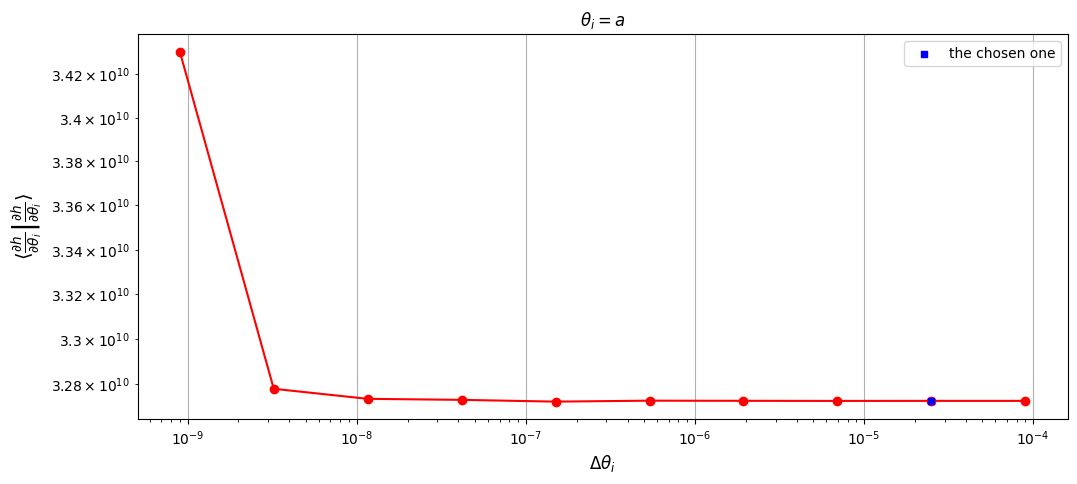

Gamma_ii for p0: 68190226332.16188
Gamma_ii for p0: 68190227466.92232
Gamma_ii for p0: 68190226926.30261
Gamma_ii for p0: 68190236097.557594
Gamma_ii for p0: 68190264680.998955
Gamma_ii for p0: 68190149390.384094
Gamma_ii for p0: 68189816643.459854
Gamma_ii for p0: 68189909375.216095
Gamma_ii for p0: 68190271307.623375
Gamma_ii for p0: 68185819517.19825
[np.float64(1.6641100626364207e-08), np.float64(7.928111249497327e-09), np.float64(1.3449513459483563e-07), np.float64(4.191718787746301e-07), np.float64(1.69072242679076e-06), np.float64(4.879715778969269e-06), np.float64(1.3599043772090488e-06), np.float64(5.30768393114614e-06), np.float64(6.528909466289049e-05)]
1


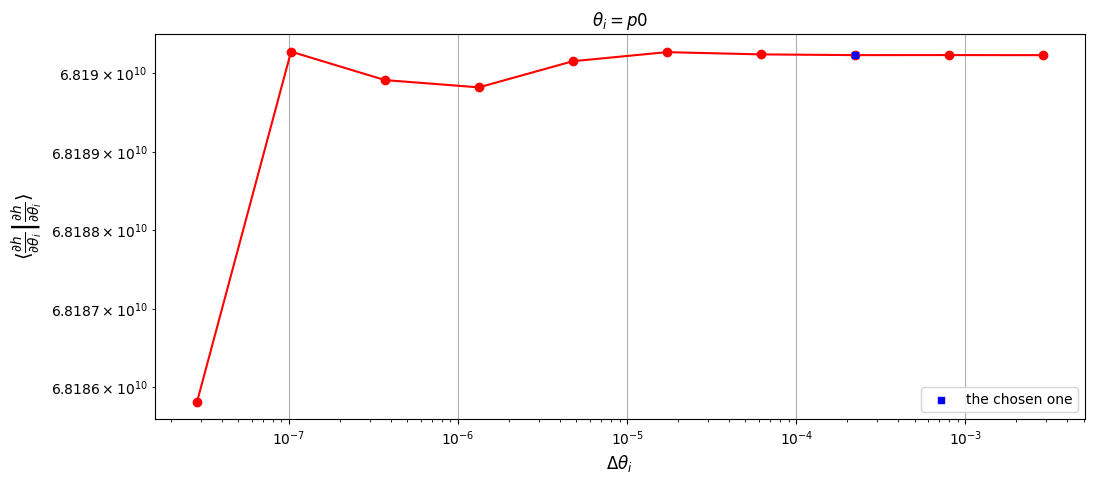

Gamma_ii for e0: 2731691089368.29
Gamma_ii for e0: 2731690819466.183
Gamma_ii for e0: 2731690224591.956
Gamma_ii for e0: 2731697212097.741
Gamma_ii for e0: 2731685742899.93
Gamma_ii for e0: 2731670525555.976
Gamma_ii for e0: 2731372202932.9233
Gamma_ii for e0: 2729634258434.1724
Gamma_ii for e0: 2733038785867.164
Gamma_ii for e0: 2724387395448.2114
[np.float64(9.880404656715031e-08), np.float64(2.177678207050875e-07), np.float64(2.5579356870926274e-06), np.float64(4.198578786320996e-06), np.float64(5.57070986846204e-06), np.float64(0.00010922078753397219), np.float64(0.0006366950053403606), np.float64(0.0012456930544114027), np.float64(0.003175536061210313)]
0


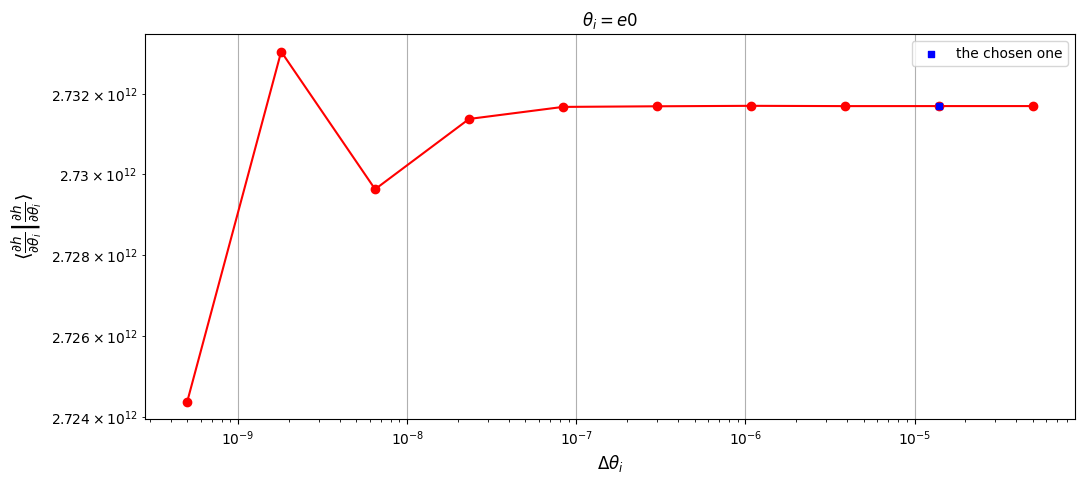

stable deltas: {'m1': 2.1544346900318834, 'm2': 0.0774263682681127, 'a': 2.5043034619864152e-05, 'p0': 0.00022129473898063854, 'e0': 1.3912797011035628e-05}
Time taken to compute stable deltas is 27.22538423538208 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 2.5121383666992188 seconds


In [5]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,
                "evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [6]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher, m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(m1), m2, a, p0, e0])

In [7]:
deviation_included=True
evolve_1PA=True
evolve_primary=False
evolve_2PA=False
use_gpu=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)

waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
PSD=xp.array(PSD)
waveform_true=xp.array(waveform_true)
waveform_true

[0.95, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


array([[ 1.74749107e-21,  1.88856152e-21,  2.02361802e-21, ...,
         1.01107469e-20,  9.52820799e-21,  8.77788922e-21],
       [ 4.38560946e-21,  4.29024432e-21,  4.19109522e-21, ...,
        -2.54720559e-21, -3.89776346e-21, -5.11994912e-21]],
      shape=(2, 788954))

In [8]:
PSD.shape

(2, 394477)

In [9]:
xp.array([xp.fft.rfft(waveform_true[k]) * dt for k in range(2)])

array([[ 1.59005809e-18+0.00000000e+00j,  1.59005863e-18+1.46682464e-22j,
         1.59006027e-18+2.93288000e-22j, ...,
        -3.34425143e-20+2.45499301e-25j, -3.34425143e-20+1.22755969e-25j,
        -3.34425143e-20+0.00000000e+00j],
       [ 1.07191369e-19+0.00000000e+00j,  1.07193497e-19+1.92507388e-22j,
         1.07199883e-19+3.85038294e-22j, ...,
         5.06442922e-20-4.23038720e-25j,  5.06442922e-20-2.11509212e-25j,
         5.06442922e-20+0.00000000e+00j]], shape=(2, 394478))

In [10]:
deviation_included=False
# evolve_1PA=True  #change it after checking
evolve_1PA=False
evolve_primary=False
evolve_2PA=False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

def loglike_calc(m1_, m2_, a_, p0_, e0_):
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T,use_gpu=use_gpu))
    diff_inner=inner_product(waveform_true-waveform_temp,waveform_true-waveform_temp,PSD,dt,use_gpu=use_gpu)
    return -0.5 * diff_inner

def timemax_correlation(h1, h2):

    # FFT with dt scaling
    H1 = xp.array([xp.fft.rfft(h1[k]) * dt for k in range(2)])
    H2 = xp.array([xp.fft.rfft(h2[k]) * dt for k in range(2)])
    # print("H1 shape: ", H1.shape
    #       ,"H2 shape: ", H2.shape)
    # print("PSD shape: ", PSD.shape)

    Y = xp.zeros_like(H1)
    for i in range(2):
        Y[i,1:] = H1[i,1:] * xp.conj(H2[i,1:]) / (0.5 * PSD[i])  # Avoid DC component
    # IFFT to time domain with proper normalization
    S =xp.array([xp.fft.irfft(Y[i]) / dt for i in range(2)])
    # Return maximum correlation
    return  xp.max(xp.abs(S))

# def timemax_correlation_davendra(h1, h2):

#     # FFT with dt scaling
#     H1 = xp.fft.fft(h1) * dt
#     H2 = xp.fft.fft(h2) *dt
#     N=len(h1[0])

#     Sn = xp.asarray(get_sensitivity(xp.abs(xp.fft.rfftfreq(N, dt)[1:]), sens_fn=CornishLISASens, return_type="PSD"))
#     # Initialize Y with zeros
#     Y = xp.zeros_like(H1)
#     # Noise-weighted correlation (skip DC)
#     Y[1:] = H1[1:] * xp.conj(H2[1:]) / (0.5 * Sn)
#     # IFFT to time domain with proper normalization
#     S = xp.fft.ifft(Y) / dt
#     # Return maximum correlation
#     return xp.max(xp.abs(S))

def loglike_calc_time_max(m1_, m2_, a_, p0_, e0_):
    waveform_temp=xp.array(superkludge_wave(m1_, m2_, a_, p0_, e0_, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T,use_gpu=use_gpu))
    max_corr = timemax_correlation(waveform_true, waveform_temp)
    return max_corr


In [11]:
def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)
    for i in range(n_samples):
        logm1_, m2_, a_, p0_, e0_ = params[i]
        m1_ = np.exp(logm1_)
        loglike = loglike_calc_time_max(m1_, m2_, a_, p0_, e0_)
        log_likes[i] = loglike 
    return log_likes

n=400
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]

def prior_transform(u):

    transformed = np.zeros_like(u)
    # Uniform in log for masses
    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    transformed[:, 1] = (m2lim[1] - m2lim[0]) * u[:, 1] + m2lim[0]
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    return transformed
    
def inverse_prior_transform(x):
    
    u = np.zeros_like(x)

    u[:, 0] = (x[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (x[:, 1] - m2lim[0]) / (m2lim[1] - m2lim[0])
    u[:, 2] = (x[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (x[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (x[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    
    return u

In [12]:
logm1lim = [max(0,params_truth_in[0] - n*std[0]), params_truth_in[0] + n*std[0]]
m2lim = [max(0,params_truth_in[1] - n*std[1]), params_truth_in[1] + n*std[1]]
alim = [max(-0.999,params_truth_in[2] - n*std[2]), min(params_truth_in[2] + n*std[2], 0.999)]  # a must be <1
p0lim = [max(0,params_truth_in[3] - n*std[3]), params_truth_in[3] + n*std[3]]
e0lim = [max(0,params_truth_in[4] - n*std[4]), min(1,params_truth_in[4] + n*std[4])]

ranges=[logm1lim, m2lim, alim, p0lim, e0lim]
ranges

[[np.float64(13.134435861519837), np.float64(14.49658525440871)],
 [np.float64(8293.456735826345), np.float64(11706.543264173655)],
 [np.float64(-0.1617567858402612), 0.999],
 [np.float64(16.95610787762675), np.float64(40.20652132237325)],
 [np.float64(0.4565000751335732), np.float64(0.5434999248664268)]]

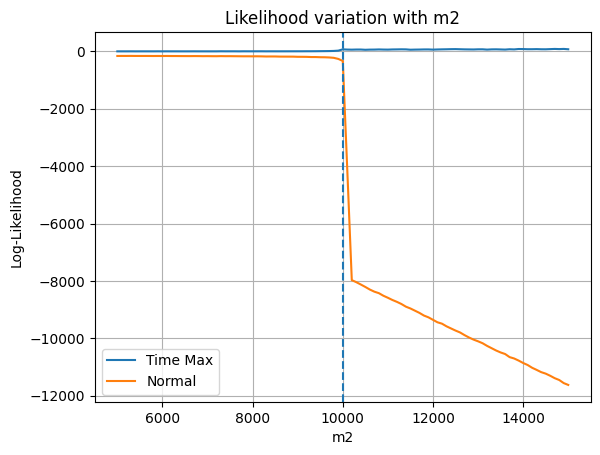

In [13]:
m2_vals = np.linspace(0.5*m2, 1.5*m2, 101)
loglikes_normal  = []
loglikes_time_max  = []

for m2_ in m2_vals:
    loglike_time_max = loglike_calc_time_max(m1, m2_, a, p0, e0)
    if hasattr(loglike_time_max, "get"):
        loglike_time_max = loglike_time_max.get()
    loglike_normal = loglike_calc(m1, m2_, a, p0, e0)
    if hasattr(loglike_normal, "get"):
        loglike_normal = loglike_normal.get()
    
    loglikes_time_max.append(loglike_time_max)
    loglikes_normal.append(loglike_normal)

loglikes_time_max = np.array(loglikes_time_max)
loglikes_normal = np.array(loglikes_normal)

# ---- Plot ----
plt.figure()
plt.plot(m2_vals, loglikes_time_max, label="Time Max")
plt.plot(m2_vals, loglikes_normal, label="Normal")
plt.axvline(m2, linestyle="--")
plt.xlabel("m2")
plt.ylabel("Log-Likelihood")
plt.title("Likelihood variation with m2")
plt.grid()
plt.legend()
plt.show()

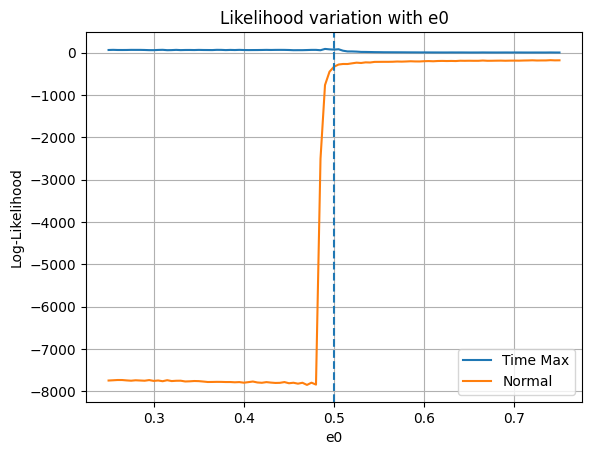

In [14]:
e0_vals = np.linspace(0.5*e0, 1.5*e0, 101)

loglikes_normal = []
loglikes_time_max = []

for e0_ in e0_vals:
    
    loglike_time_max = loglike_calc_time_max(m1, m2, a, p0, e0_)
    if hasattr(loglike_time_max, "get"):
        loglike_time_max = loglike_time_max.get()
        
    loglike_normal = loglike_calc(m1, m2, a, p0, e0_)
    if hasattr(loglike_normal, "get"):
        loglike_normal = loglike_normal.get()
    
    loglikes_time_max.append(loglike_time_max)
    loglikes_normal.append(loglike_normal)

loglikes_time_max = np.array(loglikes_time_max)
loglikes_normal = np.array(loglikes_normal)

# ---- Plot ----
plt.figure()
plt.plot(e0_vals, loglikes_time_max, label="Time Max")
plt.plot(e0_vals, loglikes_normal, label="Normal")
plt.axvline(e0, linestyle="--")
plt.xlabel("e0")
plt.ylabel("Log-Likelihood")
plt.title("Likelihood variation with e0")
plt.grid()
plt.legend()
plt.show()

In [17]:
np.max(loglikes_time_max), np.max(loglikes_normal)

(np.float64(155.23329824523483), np.float64(-0.0))

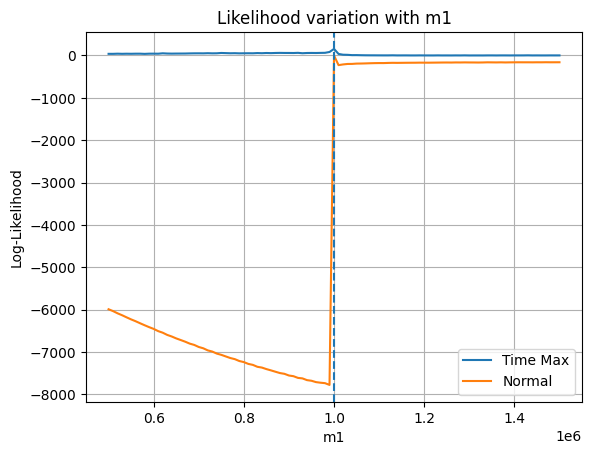

In [18]:
m1_vals = np.linspace(0.5*m1, 1.5*m1, 101)

loglikes_normal = []
loglikes_time_max = []

for m1_ in m1_vals:
    
    loglike_time_max = loglike_calc_time_max(m1_, m2, a, p0, e0)
    if hasattr(loglike_time_max, "get"):
        loglike_time_max = loglike_time_max.get()
        
    loglike_normal = loglike_calc(m1_, m2, a, p0, e0)
    if hasattr(loglike_normal, "get"):
        loglike_normal = loglike_normal.get()
    
    loglikes_time_max.append(loglike_time_max)
    loglikes_normal.append(loglike_normal)

loglikes_time_max = np.array(loglikes_time_max)
loglikes_normal = np.array(loglikes_normal)

# ---- Plot ----
plt.figure()
plt.plot(m1_vals, loglikes_time_max, label="Time Max")
plt.plot(m1_vals, loglikes_normal, label="Normal")
plt.axvline(m1, linestyle="--")
plt.xlabel("m1")
plt.ylabel("Log-Likelihood")
plt.title("Likelihood variation with m1")
plt.grid()
plt.legend()
plt.show()

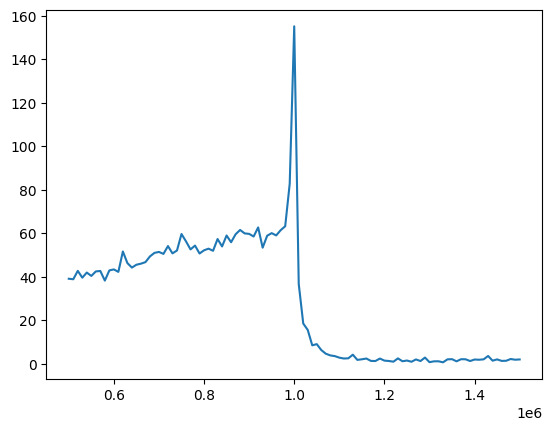

In [19]:
plt.plot(m1_vals, loglikes_time_max, label="Time Max")

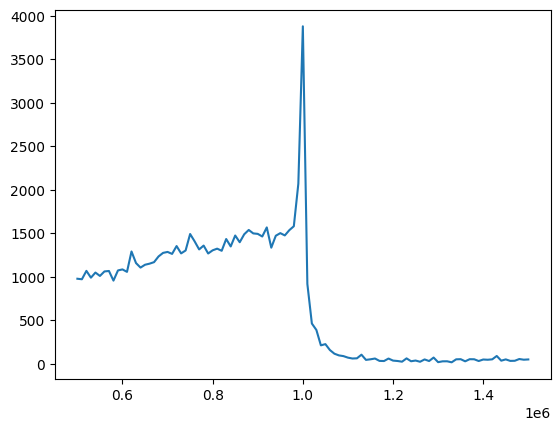

In [85]:
plt.plot(m1_vals, loglikes_time_max, label="Time Max")

In [39]:
loglike_calc_time_max(m1, m2, a, p0, e0)

array(70.34039569)

In [40]:
loglike_calc(m1, m2, a, p0, e0)


np.float64(-333.35202941189095)

In [72]:
config = SamplerConfig(
    merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
    alpha=10000,                    # Use recent samples for weighting
    trail_size=int(1e3),          # Maximum trials per iteration
    boundary_limiting=True,        # Enable boundary constraints
    use_beta=True,                # Use beta correction for boundaries
    integral_num=int(1e5),        # MC samples for beta estimation
    gamma=500,                    # Covariance update frequency
    exclude_scale_z=10,       # No exclusion based on weights
    use_pool=False,               # Set to True for multiprocessing
    cov_jitter=1e-10,             # Jitter added to covariance for stability

    # n_pool=4                     # Number of processes (if use_pool=True)
)

ndim = 5
n_seed = int(5e4)  # Number of initial processes
init_cov_list = [np.eye(ndim) * 1e-10] * n_seed
savepath = 'paris_1PA_vs_0PA_5_params_2'  # Directory to save results

# Create save directory
os.makedirs(savepath, exist_ok=True)

print(f"Problem dimension: {ndim}")
print(f"Number of processes: {n_seed}")
print(f"Save path: {savepath}")
print(f"Multiprocessing: {config.use_pool}")
# Initialize sampler
print("\nInitializing sampler...")
sampler = Sampler(
    ndim=ndim, 
    n_seed=n_seed,
    log_density_func=log_density,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)
   # Prepare initial samples using Latin Hypercube Sampling
print("Preparing LHS samples...")

#best value got so far
true_point = np.array([0.57833453, 0.44849699, 0.56882998, 0.4387439 , 0.22527571])

rng = np.random.default_rng(42)
scatter = 1.0e-8
points = true_point + rng.normal(size=(n_seed-1, 5)) * scatter
external_lhs_points = np.vstack([points, true_point])
print("Shape of points array:", external_lhs_points.shape)
external_lhs_log_densities = log_density(prior_transform(external_lhs_points))
print("true points in corrrect space",params_truth_in)
print("external_lhs_log_densities", external_lhs_log_densities)


sampler.run_sampling(
            num_iterations=int(1e5),
            savepath=savepath,
            print_iter=100,
            external_lhs_points=external_lhs_points,
            external_lhs_log_densities=external_lhs_log_densities,
            stop_dlogZ=0.005
        )
#except Exception as exc:
 #       print(f"[WARN] PARIS sampling failed: {exc}")
    
# Gt results
print("Extracting results...")
samples_, weights_ = sampler.get_samples_with_weights(flatten=True)

# Basic analysis
print(f"\nResults Summary:")
print(f"Total samples: {len(samples_)}")
print(f"Effective sample size: {1/np.sum(weights_  **2):.1f}")

# Weighted statistics
weighted_mean = np.average(samples_, weights=weights_, axis=0)
weighted_cov = np.cov(samples_.T, aweights=weights_)

print(f"\nTrue values: {params_truth_in}")
print(f"Estimated deviation: {weighted_mean}")
print(f"Mean deviation: {np.linalg.norm(weighted_mean - params_truth_in[0:5]):.6f}")

print(f"\nTrue covariance diagonal: {np.diag(cov)}")
print(f"Estimated covariance diagonal: {np.diag(weighted_cov)}")

Problem dimension: 5
Number of processes: 50000
Save path: paris_1PA_vs_0PA_5_params_2
Multiprocessing: False

Initializing sampler...
Preparing LHS samples...
Shape of points array: (50000, 5)


KeyboardInterrupt: 

In [41]:
# best_fit_tn=external_lhs_points[np.argmax(external_lhs_log_densities)]
# print(np.max(external_lhs_log_densities))
# print(best_fit_tn)
# prior_transform(np.array([best_fit_tn]))

In [14]:
params_truth_in

array([1.38155106e+01, 1.00000000e+04, 9.00000000e-01, 2.85813146e+01,
       5.00000000e-01])

## overlap - 0.0004617823498656426
### [1.41750884e+01, 1.10072692e+04 ,9.87439906e-01, 2.11507037e+01,5.11068281e-01]
##
### [1.38251836e+01,9.98387483e+03,9.13306537e-01,2.84510455e+01,4.97884338e-01] -> overlap (0.8703736643512113)
##
### [1.38245383e+01, 9.98581431e+03, 9.12229447e-01, 2.84623748e+01,4.97910117e-01] -> 0.8697589800101326

#

In [20]:
print(log_density([params_truth_in[0:5]]))
log_density([ [1.38245383e+01, 9.98581431e+03, 9.12229447e-01, 2.84623748e+01,
 4.97910117e-01]])


[70.34039569]


array([135.45393944])

In [21]:
inverse_prior_transform(np.array([[1.38251836e+01,9.98387483e+03,9.13306537e-01,2.84510455e+01,4.97884338e-01]]))

array([[0.50710131, 0.49527549, 0.92617449, 0.49439713, 0.475682  ]])

In [28]:
best_fit_point =  [1.38251836e+01,9.98387483e+03,9.13306537e-01,2.84510455e+01,4.97884338e-01]

In [29]:
add_args

[0.95, False, False, False, False, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [30]:
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

waveform_approx = superkludge_wave(np.exp(best_fit_point[0]), best_fit_point[1], best_fit_point[2], best_fit_point[3],
                                    best_fit_point[4], xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

overlap between best fit point and true waveform: 0.8703736643512113
mismatch between best fit point and true waveform: 0.12962633564878867


In [ ]:
def timemax_correlation(self, h1, h2):
    """
    Find maximum noise-weighted correlation between two waveforms.
    Uses FFT-based correlation with LISA noise weighting to find the maximum
    correlation over all time shifts.
    Parameters:
    -----------
    h1, h2 : array
        Time-domain waveforms (complex arrays)
    Returns:
    --------
    float
        Maximum correlation value over all time shifts
    """
    # FFT with dt scaling
    H1 = self.xp.fft.fft(h1) * self.dt
    H2 = self.xp.fft.fft(h2) * self.dt
    # Get PSD at full FFT frequencies (skip DC), using absolute value for negative frequencies
    Sn = self.xp.asarray(get_sensitivity(self.xp.abs(self.fft_freqs[1:]), sens_fn=CornishLISASens, return_type="PSD"))
    # Initialize Y with zeros
    Y = self.xp.zeros_like(H1)
    # Noise-weighted correlation (skip DC)
    Y[1:] = H1[1:] * self.xp.conj(H2[1:]) / (0.5 * Sn)
    # IFFT to time domain with proper normalization
    S = self.xp.fft.ifft(Y) / self.dt
    # Return maximum correlation
    return self.xp.max(self.xp.abs(S))

def Xstat_timemax(self, x, h):
        """
        Compute time-and-phase-maximized detection statistic with PSD weighting.

        Returns max_τ,φ |<x|h(τ,φ)>|_weighted / sqrt(<h|h>)

        Should peak at SNR when x=h.
        Uses FFT-based cross-correlation to efficiently maximize over all time shifts.

        Parameters:
        -----------
        x : array
            Time-domain data signal
        h : array
            Time-domain template waveform

        Returns:
        --------
        float
            Maximum correlation over time and phase shifts normalized by template SNR
        """
        # Time-maximized correlation
        calc_inner_complex = self.timemax_correlation(x, h)
        calc_SNR = self.xp.sqrt(self.timemax_correlation(h, h))

        # Normalized detection statistic
        return calc_inner_complex / calc_SNR
    
def Xstat(self, x, h):
        """
        Compute the standard detection statistic for gravitational wave data.

        Returns |<x|h>| / sqrt(<h|h>)
        """

        xf = self.freq_wave(x)
        hf = self.freq_wave(h)

        # Get COMPLEX inner product for phase maximization
        calc_inner_complex = self.inner(xf, hf, return_complex=True)
        calc_SNR = self.xp.sqrt(self.inner(hf, hf))

        # NOTE: Phase-marginalized (maximizes over Phi_phi0, Phi_r0, etc)
        return self.xp.abs(calc_inner_complex) / calc_SNR

        # NOTE: Phase-dependent version
        # calc_inner_real = self.inner(xf, hf, return_complex=False)
        # return calc_inner_real / calc_SNR


def inner(self, h1f, h2f, return_complex=False):
        """
        Compute the inner product of two gravitational waveforms.

        Parameters:
        h1f, h2f (numpy.ndarray or cupy.ndarray): Frequency domain waveforms.
        return_complex (bool): If True, return complex inner product.
                               If False, return real part only (default, backward compatible)

        Returns:
        float or complex: Inner product of the two waveforms.
        """

        df = 1/(self.N*self.dt)  # Frequency resolution

        # Get sensitivity (using rfft frequencies for this method since h1f/h2f come from freq_wave which uses rfft)
        Sn = get_sensitivity(self.fft_freqs_rfft[1:], sens_fn=CornishLISASens, return_type="PSD")
        # Sn = LISA_Noise(self.fft_freqs_rfft[1:])

        # Compute the inner product using backend operations
        plus = self.xp.conj(h1f[0,1:]) @ (h2f[0,1:] / Sn)
        cross = self.xp.conj(h1f[1,1:]) @ (h2f[1,1:] / Sn)

        inner_prod = 4*df*(plus+cross)

        if return_complex:
            return inner_prod
        else:
            # OLD behavior: return real part only
            return self.xp.real(inner_prod)